### 数据的两种加载策略 (Core Concept)

实验通过对比两种方式，让你理解它们在资源消耗和效率上的差异：

- **Memory-Based (基于内存):** 将所有数据一次性加载到内存（RAM）中。这适用于小型数据集，速度快但极其消耗内存。

- **Generator-Based (基于生成器/批次):** 使用 Python 生成器或 `tf.data.Dataset` / `DataLoader` 边训练边从磁盘读取数据。这是处理海量数据（如数万张卫星图像）的工业级标准做法。

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork

from PIL import Image

In [21]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"

extraction_path = "./data"
await skillsnetwork.prepare(url = url, path = extraction_path, overwrite = True)

  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to 'data'


In [22]:
extract_dir = "./data"

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [23]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_25907.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25984.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15608.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3487.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_14258.jpg'>


查看图片shape

In [29]:
file_name = next(non_agri)
image_name = str(file_name).split("'")[1]
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data.shape

(64, 64, 3)

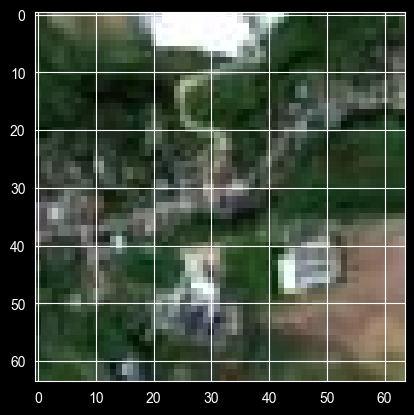

In [30]:
plt.imshow(image_data)

display the first 4 images in non_agir collection

In [31]:
non_agri_images = os.listdir(dir_non_agri)
non_agri_images_paths = [os.path.join(dir_non_agri, image) for image in non_agri_images]
#print first five paths
len(non_agri_images_paths)

3000

In [34]:
non_agri_images_paths[0]

'./data/images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_25907.jpg'

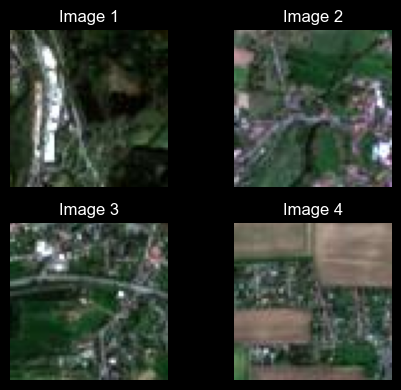

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(5, 4))

for i, ax in enumerate(axes.flat):
    if i < 4:
        img = plt.imread(non_agri_images_paths[i])
        ax.imshow(img)
        ax.set_title(f'Image {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [40]:
agri_images = os.listdir(dir_agri)
agri_images_paths = [os.path.join(dir_agri, image) for image in agri_images]

In [41]:
agri_images_paths[0]

'./data/images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_5974.jpg'

In [42]:
len(agri_images_paths)

3000

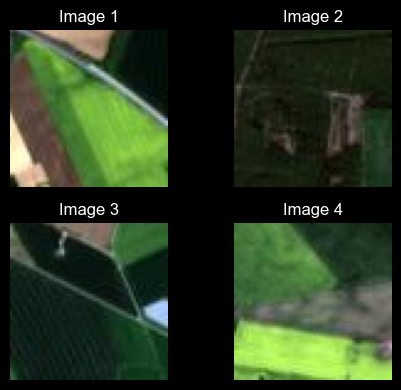

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(5, 4))

for i, ax in enumerate(axes.flat):
    if i < 4:
        img = plt.imread(agri_images_paths[i])
        ax.imshow(img)
        ax.set_title(f'Image {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()